# mBERT GloSeGAT Result Analysis

This notebook prepares three result analyses for the mBERT GloSeGAT architecture:

1. **Incremental ablation trained from scratch** using the best GloSeGAT hyperparameters for all ablation stages: `PairCLS`, `TargetSim`, `GlossOnly`, `GATOnly`, and `GloSeGAT`.
2. **Surrogate interpretability** of the GloSeGAT feature vector
   $z = [h_1; h_2; |h_1-h_2|; h_1 \odot h_2; r_1; r_2; |r_1-r_2|; r_1 \odot r_2; \cos(h_1,r_1); \cos(h_2,r_2); q_1; q_2; |q_1-q_2|; q_1 \odot q_2; \cos(h_1,q_1); \cos(h_2,q_2)]$.
3. **GNNExplainer-style explanation** for a cross-lingual example correctly classified by GloSeGAT and incorrectly classified by TargetPOS.

The notebook is Colab-compatible. In Colab, upload or clone the `Experiments` folder so that `Bert-base/mcl_wic_colab_common.py` and `Bert-base/Results/gat/summary.json` are available. Set `RUN_ABLATION_TRAINING = True` to run the full ablation training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import os
import sys
import math
import random
import subprocess
from collections import defaultdict

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'transformers', 'nltk', 'scikit-learn', 'networkx'])


def resolve_base_dir():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / 'Experiments',
        Path('/content/Experiments'),
        Path('/content/drive/MyDrive/Experiments'),
        Path('/content/drive/MyDrive/MCL-WiC/Experiments'),
        Path('/content/drive/MyDrive/repositorios/Experiments'),
    ]
    for candidate in candidates:
        if (candidate / 'Bert-base' / 'mcl_wic_colab_common.py').exists():
            return candidate
    if cwd.name != 'Experiments':
        return cwd / 'Experiments'
    return cwd

BASE_DIR = resolve_base_dir()
REPO_DIR = BASE_DIR.parent
MBERT_RESULTS_DIR = BASE_DIR / 'analysis_outputs_mbert'
RAW_RESULTS_DIR = BASE_DIR / 'Bert-base' / 'Results'
OUTPUT_DIR = BASE_DIR / 'glosegat_mbert_analysis_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_ROOT = REPO_DIR / 'GLOWiC-2S' / 'data' / 'external' / 'mcl-wic' / 'extracted'
if not DATA_ROOT.exists():
    DATA_ROOT = Path('/content/mcl-wic/extracted')

MODEL_NAME = 'bert-base-multilingual-cased'
DEVICE = 'auto'
SEED = 1000
DOWNLOAD_DATA = True if IN_COLAB else False

MONOLINGUAL_SPLITS = ['test.en-en']
MULTILINGUAL_SPLITS = ['test.ar-ar', 'test.fr-fr', 'test.ru-ru', 'test.zh-zh']
CROSSLINGUAL_SPLITS = ['test.en-ar', 'test.en-fr', 'test.en-ru', 'test.en-zh']
TEST_SPLITS = MONOLINGUAL_SPLITS + MULTILINGUAL_SPLITS + CROSSLINGUAL_SPLITS
DATASET_GROUPS = {
    'Overall': TEST_SPLITS,
    'Monolingual': MONOLINGUAL_SPLITS,
    'Multilingual': MULTILINGUAL_SPLITS,
    'Cross-lingual': CROSSLINGUAL_SPLITS,
}

SPLIT_LABELS = {
    'test.en-en': 'En-En',
    'test.ar-ar': 'Ar-Ar',
    'test.fr-fr': 'Fr-Fr',
    'test.ru-ru': 'Ru-Ru',
    'test.zh-zh': 'Zh-Zh',
    'test.en-ar': 'En-Ar',
    'test.en-fr': 'En-Fr',
    'test.en-ru': 'En-Ru',
    'test.en-zh': 'En-Zh',
}

COMMON_PATH = BASE_DIR / 'Bert-base' / 'mcl_wic_colab_common.py'
if not COMMON_PATH.exists():
    raise FileNotFoundError(f'Missing {COMMON_PATH}. In Colab, upload/clone the Experiments folder first.')
if str(COMMON_PATH.parent) not in sys.path:
    sys.path.insert(0, str(COMMON_PATH.parent))

import importlib.util
spec = importlib.util.spec_from_file_location('mcl_wic_colab_common_mbert', COMMON_PATH)
common = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = common
spec.loader.exec_module(common)

print('IN_COLAB =', IN_COLAB)
print('BASE_DIR =', BASE_DIR)
print('DATA_ROOT =', DATA_ROOT)
print('OUTPUT_DIR =', OUTPUT_DIR)
print('COMMON_PATH =', COMMON_PATH)

IN_COLAB = True
BASE_DIR = /content/drive/MyDrive/MCL-WiC/Experiments
DATA_ROOT = /content/mcl-wic/extracted
OUTPUT_DIR = /content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs
COMMON_PATH = /content/drive/MyDrive/MCL-WiC/Experiments/Bert-base/mcl_wic_colab_common.py


## 1. Incremental Ablation Trained from Scratch

This section trains the ablation variants from zero using the **best hyperparameters selected for mBERT GloSeGAT**. The same hyperparameter configuration is applied to all stages so that the comparison isolates architectural changes rather than tuning differences.

Ablation stages:

1. `PairCLS`: BERT [CLS] baseline.
2. `TargetSim`: target-aware Transformer.
3. `GlossOnly`: target-aware Transformer + dictionary/gloss sense attention, no graph refinement.
4. `GATOnly`: target-aware Transformer + graph-refined sense representations, without raw gloss features in the classifier.
5. `GloSeGAT`: complete architecture with dictionary/gloss sense attention and graph-refined sense representations.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

RUN_ABLATION_TRAINING = True  # Set True in Google Colab to train the ablation from scratch.
ABLATION_SEEDS = [1000]
ABLATION_MAX_EPOCHS = 5
ABLATION_PATIENCE = 2
ABLATION_NUM_WORKERS = 2 if IN_COLAB else 0
ABLATION_FORCE_RETRAIN = False
ABLATION_CHECKPOINT_DIR = OUTPUT_DIR / 'ablation_checkpoints'
ABLATION_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ABLATION_VARIANTS = [
    ('PairCLS', 'bert_cls'),
    ('TargetSim', 'glowic_target'),
    ('GlossOnly', 'gloss_only'),
    ('GATOnly', 'gat_only'),
    ('GloSeGAT', 'glowic_gat'),
]

def load_glosegat_hparams():
    for name in ['summary.json', 'optuna_trials.json']:
        path = RAW_RESULTS_DIR / 'gat' / name
        if path.exists():
            payload = json.loads(path.read_text(encoding='utf-8'))
            return dict(payload['best_hparams'])
    raise FileNotFoundError(f'Could not find GloSeGAT best hyperparameters under {RAW_RESULTS_DIR / "gat"}')

GLOSEGAT_HPARAMS = load_glosegat_hparams()
print('GloSeGAT hparams reused for all ablations:', GLOSEGAT_HPARAMS)

GloSeGAT hparams reused for all ablations: {'lr_encoder': 2.6176655097040075e-05, 'lr_head': 0.0004176805377655882, 'weight_decay': 0.00884925020519195, 'dropout': 0.10879485872574356, 'batch_size': 8, 'warmup_ratio': 0.040702354766084387, 'topk': 7}


In [ ]:
class GlossOnlyClassifier(common.TargetGATClassifier):
    def __init__(self, model_name: str, dropout: float, topk: int, max_len: int):
        super().__init__(model_name=model_name, dropout=dropout, topk=topk, max_len=max_len)
        hidden = self.encoder.config.hidden_size
        input_dim = hidden * 8 + 2
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, batch: dict) -> torch.Tensor:
        device = batch['input_ids_1'].device
        h1 = self.encode_target(batch['input_ids_1'], batch['attention_mask_1'], batch['target_index_1'])
        h2 = self.encode_target(batch['input_ids_2'], batch['attention_mask_2'], batch['target_index_2'])
        r1_list, r2_list = [], []
        for b, (lemma, pos, wn_lang) in enumerate(zip(batch['lemmas'], batch['poses'], batch['wn_langs'])):
            gloss_emb, _ = self.get_candidate_embeddings(lemma, pos, wn_lang, device)
            r1_list.append(self.attend_candidates(h1[b:b + 1], gloss_emb))
            r2_list.append(self.attend_candidates(h2[b:b + 1], gloss_emb))
        r1 = torch.cat(r1_list, dim=0)
        r2 = torch.cat(r2_list, dim=0)
        features = torch.cat([
            h1, h2, (h1 - h2).abs(), h1 * h2,
            r1, r2, (r1 - r2).abs(), r1 * r2,
            self.cos(h1, r1).unsqueeze(-1),
            self.cos(h2, r2).unsqueeze(-1),
        ], dim=-1)
        return self.classifier(features).squeeze(-1)


class GATOnlyClassifier(common.TargetGATClassifier):
    def __init__(self, model_name: str, dropout: float, topk: int, max_len: int):
        super().__init__(model_name=model_name, dropout=dropout, topk=topk, max_len=max_len)
        hidden = self.encoder.config.hidden_size
        input_dim = hidden * 8 + 2
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, batch: dict) -> torch.Tensor:
        device = batch['input_ids_1'].device
        h1 = self.encode_target(batch['input_ids_1'], batch['attention_mask_1'], batch['target_index_1'])
        h2 = self.encode_target(batch['input_ids_2'], batch['attention_mask_2'], batch['target_index_2'])
        q1_list, q2_list = [], []
        for b, (lemma, pos, wn_lang) in enumerate(zip(batch['lemmas'], batch['poses'], batch['wn_langs'])):
            _, graph_emb = self.get_candidate_embeddings(lemma, pos, wn_lang, device)
            q1_list.append(self.attend_candidates(h1[b:b + 1], graph_emb))
            q2_list.append(self.attend_candidates(h2[b:b + 1], graph_emb))
        q1 = torch.cat(q1_list, dim=0)
        q2 = torch.cat(q2_list, dim=0)
        features = torch.cat([
            h1, h2, (h1 - h2).abs(), h1 * h2,
            q1, q2, (q1 - q2).abs(), q1 * q2,
            self.cos(h1, q1).unsqueeze(-1),
            self.cos(h2, q2).unsqueeze(-1),
        ], dim=-1)
        return self.classifier(features).squeeze(-1)


def build_ablation_model(variant: str, model_name: str, hparams: dict, max_len: int):
    dropout = hparams['dropout']
    topk = int(hparams.get('topk', 5))
    if variant in {'bert_cls', 'glowic_target', 'glowic_gat'}:
        return common.build_model(variant, model_name, dropout, topk=topk, max_len=max_len)
    if variant == 'gloss_only':
        return GlossOnlyClassifier(model_name, dropout=dropout, topk=topk, max_len=max_len)
    if variant == 'gat_only':
        return GATOnlyClassifier(model_name, dropout=dropout, topk=topk, max_len=max_len)
    raise ValueError(f'Unknown ablation variant: {variant}')


def build_ablation_datasets(variant: str, rows_by_split, tokenizer, max_len: int):
    if variant == 'bert_cls':
        return common.build_datasets('bert_cls', rows_by_split, tokenizer, max_len)
    return {k: common.TargetDataset(v, tokenizer, max_len) for k, v in rows_by_split.items()}, True

In [ ]:
def train_ablation_once(label: str, variant: str, seed: int, rows_by_split, tokenizer, cfg, hparams):
    device = common.pick_device(DEVICE)
    ckpt_path = ABLATION_CHECKPOINT_DIR / f'{label}_seed_{seed}.pt'
    result_path = ABLATION_CHECKPOINT_DIR / f'{label}_seed_{seed}.json'
    if result_path.exists() and ckpt_path.exists() and not ABLATION_FORCE_RETRAIN:
        return json.loads(result_path.read_text(encoding='utf-8'))

    common.clear_device_cache()
    common.set_seed(seed)
    if variant in {'gloss_only', 'gat_only', 'glowic_gat'}:
        common.ensure_wordnet()

    datasets, target_style = build_ablation_datasets(variant, rows_by_split, tokenizer, cfg.max_len)
    loaders = common.make_loaders(datasets, tokenizer, hparams['batch_size'], cfg.num_workers, target_style, device)
    model = build_ablation_model(variant, cfg.model_name, hparams, cfg.max_len).to(device)
    model.encoder.resize_token_embeddings(len(tokenizer))

    optimizer = common.optimizer_for(model, hparams['lr_encoder'], hparams['lr_head'], hparams['weight_decay'])
    total_steps = cfg.max_epochs * math.ceil(len(loaders['train.en-en']))
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * hparams['warmup_ratio']),
        num_training_steps=total_steps,
    )

    best_dev_accuracy = -1.0
    best_state = None
    no_improve = 0
    history = []
    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        total_loss = 0.0
        for batch in loaders['train.en-en']:
            batch = common.move_batch(batch, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch)
            loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        dev_metrics = common.evaluate(model, loaders['dev.en-en'], device)
        history.append({'epoch': epoch, 'train_loss': total_loss / max(len(loaders['train.en-en']), 1), 'dev': dev_metrics})
        print(f'{label} seed={seed} epoch={epoch} dev_acc={dev_metrics["accuracy"]:.4f}')
        if dev_metrics['accuracy'] > best_dev_accuracy:
            best_dev_accuracy = dev_metrics['accuracy']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= cfg.patience:
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    if hasattr(model, 'reset_sense_cache'):
        model.reset_sense_cache()
    final = {split: common.evaluate(model, loaders[split], device) for split in ['dev.en-en'] + TEST_SPLITS}
    result = {
        'label': label,
        'variant': variant,
        'seed': seed,
        'hparams_source': 'mBERT GloSeGAT best hparams',
        'hparams': hparams,
        'best_dev_accuracy': best_dev_accuracy,
        'history': history,
        'final': final,
    }
    torch.save({'model_state': model.state_dict(), 'result': result}, ckpt_path)
    result_path.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding='utf-8')
    del model, optimizer, scheduler, loaders, datasets
    common.clear_device_cache()
    return result


def run_ablation_training_from_scratch():
    cfg = common.ExperimentConfig(
        variant='ablation',
        data_root=str(DATA_ROOT),
        output_dir=str(OUTPUT_DIR),
        model_name=MODEL_NAME,
        n_trials=0,
        n_seed_runs=len(ABLATION_SEEDS),
        max_epochs=ABLATION_MAX_EPOCHS,
        patience=ABLATION_PATIENCE,
        max_len=128,
        seed=42,
        seed_start=min(ABLATION_SEEDS),
        train_limit=None,
        eval_limit=None,
        num_workers=ABLATION_NUM_WORKERS,
        device=str(common.pick_device(DEVICE)),
        freeze_encoder=False,
        download_data=DOWNLOAD_DATA,
    )
    rows_by_split = common.load_all_rows(cfg)
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
    tokenizer.add_special_tokens({'additional_special_tokens': [common.TARGET_START, common.TARGET_END]})
    print('Dataset sizes:', {k: len(v) for k, v in rows_by_split.items()})

    runs = []
    for label, variant in ABLATION_VARIANTS:
        for seed in ABLATION_SEEDS:
            runs.append(train_ablation_once(label, variant, seed, rows_by_split, tokenizer, cfg, GLOSEGAT_HPARAMS))
    summary_path = OUTPUT_DIR / 'trained_ablation_seed_runs.json'
    summary_path.write_text(json.dumps(runs, indent=2, ensure_ascii=False), encoding='utf-8')
    return runs

if RUN_ABLATION_TRAINING:
    ablation_runs = run_ablation_training_from_scratch()
else:
    existing = OUTPUT_DIR / 'trained_ablation_seed_runs.json'
    if existing.exists():
        ablation_runs = json.loads(existing.read_text(encoding='utf-8'))
        print(f'Loaded existing trained ablation runs: {existing}')
    else:
        ablation_runs = []
        print('Ablation training skipped. Set RUN_ABLATION_TRAINING = True in Colab to train from scratch.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GATOnly seed=1000 epoch=1 dev_acc=0.8160
GATOnly seed=1000 epoch=2 dev_acc=0.8160
GATOnly seed=1000 epoch=3 dev_acc=0.8240
GATOnly seed=1000 epoch=4 dev_acc=0.8250
GATOnly seed=1000 epoch=5 dev_acc=0.8270


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GloSeGAT seed=1000 epoch=1 dev_acc=0.7890
GloSeGAT seed=1000 epoch=2 dev_acc=0.8010
GloSeGAT seed=1000 epoch=3 dev_acc=0.8270
GloSeGAT seed=1000 epoch=4 dev_acc=0.8390
GloSeGAT seed=1000 epoch=5 dev_acc=0.8230


In [ ]:
def summarize_trained_ablation(ablation_runs):
    rows = []
    for run in ablation_runs:
        for split, metrics in run['final'].items():
            if split not in TEST_SPLITS:
                continue
            for group_name, group_splits in DATASET_GROUPS.items():
                if split in group_splits:
                    rows.append({
                        'stage': run['label'],
                        'variant': run['variant'],
                        'seed': run['seed'],
                        'split': split,
                        'dataset_type': group_name,
                        'accuracy': metrics['accuracy'],
                        'f1': metrics['f1'],
                        'loss': metrics['loss'],
                    })
    long_df = pd.DataFrame(rows)
    if long_df.empty:
        return long_df, pd.DataFrame(), pd.DataFrame()
    summary = (
        long_df.groupby(['stage', 'variant', 'dataset_type'])
        .agg(
            accuracy_mean_pct=('accuracy', lambda x: 100 * x.mean()),
            accuracy_std_pct=('accuracy', lambda x: 100 * x.std(ddof=1)),
            f1_mean_pct=('f1', lambda x: 100 * x.mean()),
            n_observations=('accuracy', 'size'),
            n_splits=('split', 'nunique'),
            n_seeds=('seed', 'nunique'),
        )
        .reset_index()
    )
    stage_order = [label for label, _ in ABLATION_VARIANTS]
    dtype_order = ['Overall', 'Monolingual', 'Multilingual', 'Cross-lingual']
    summary['stage'] = pd.Categorical(summary['stage'], categories=stage_order, ordered=True)
    summary['dataset_type'] = pd.Categorical(summary['dataset_type'], categories=dtype_order, ordered=True)
    summary = summary.sort_values(['stage', 'dataset_type'])
    wide = summary.pivot(index=['stage', 'variant'], columns='dataset_type', values='accuracy_mean_pct')
    wide = wide[['Overall', 'Monolingual', 'Multilingual', 'Cross-lingual']].reset_index()
    wide['stage'] = pd.Categorical(wide['stage'], categories=stage_order, ordered=True)
    wide = wide.sort_values('stage')
    return long_df, summary, wide

trained_ablation_long, trained_ablation_summary, trained_ablation_wide = summarize_trained_ablation(ablation_runs)
if not trained_ablation_summary.empty:
    trained_ablation_long.to_csv(OUTPUT_DIR / 'trained_ablation_long.csv', index=False)
    trained_ablation_summary.to_csv(OUTPUT_DIR / 'trained_ablation_by_dataset_type.csv', index=False)
    trained_ablation_wide.to_csv(OUTPUT_DIR / 'trained_ablation_wide.csv', index=False)
    display(trained_ablation_summary)
    display(trained_ablation_wide)
else:
    print('No trained ablation results available yet.')

,stage,variant,dataset_type,accuracy_mean_pct,accuracy_std_pct,f1_mean_pct,n_observations,n_splits,n_seeds
15,PairCLS,bert_cls,Overall,70.677778,7.197357,64.700234,9,9,1
13,PairCLS,bert_cls,Monolingual,81.600000,NaN,81.526104,1,1,1
14,PairCLS,bert_cls,Multilingual,74.825000,1.785824,75.896990,4,4,1
12,PairCLS,bert_cls,Cross-lingual,63.800000,3.029851,49.297011,4,4,1
19,TargetSim,glowic_target,Overall,78.733333,3.689851,78.453964,9,9,1
17,TargetSim,glowic_target,Monolingual,84.100000,NaN,84.985836,1,1,1
18,TargetSim,glowic_target,Multilingual,77.450000,2.817209,79.202678,4,4,1
16,TargetSim,glowic_target,Cross-lingual,78.675000,4.070524,76.072283,4,4,1
11,GlossOnly,gloss_only,Overall,77.311111,5.787367,76.068506,9,9,1
9,GlossOnly,gloss_only,Monolingual,86.600000,NaN,87.358491,1,1,1


dataset_type,stage,variant,Overall,Monolingual,Multilingual,Cross-lingual
0,PairCLS,bert_cls,70.677778,81.6,74.825,63.800
1,TargetSim,glowic_target,78.733333,84.1,77.450,78.675
2,GlossOnly,gloss_only,77.311111,86.6,75.675,76.625
3,GATOnly,gat_only,79.088889,85.0,76.350,80.350
4,GloSeGAT,glowic_gat,79.122222,83.5,76.675,80.475


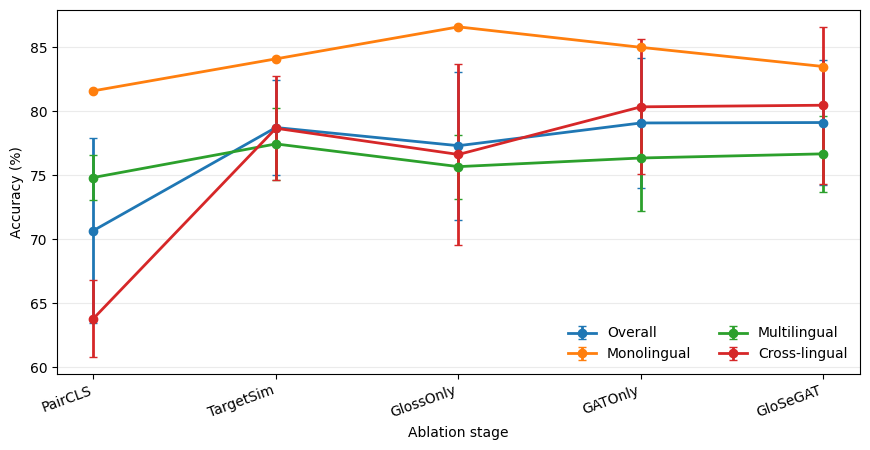

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/trained_incremental_ablation_accuracy.png


In [ ]:
if not trained_ablation_summary.empty:
    fig, ax = plt.subplots(figsize=(8.8, 4.6))
    for group_name in ['Overall', 'Monolingual', 'Multilingual', 'Cross-lingual']:
        sub = trained_ablation_summary[trained_ablation_summary['dataset_type'] == group_name]
        ax.errorbar(sub['stage'], sub['accuracy_mean_pct'], yerr=sub['accuracy_std_pct'], marker='o', linewidth=2, capsize=3, label=group_name)
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('Ablation stage')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    fig_path = OUTPUT_DIR / 'trained_incremental_ablation_accuracy.png'
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(fig_path)
else:
    print('Skipped plot because trained ablation results are not available.')

In [ ]:
def trained_ablation_table_to_latex(df):
    if df.empty:
        return '% No trained ablation results available yet.'
    table = df.copy()
    for col in ['Overall', 'Monolingual', 'Multilingual', 'Cross-lingual']:
        table[col] = table[col].map(lambda x: f'{x:.2f}')
    rows = []
    rows.append('\\begin{table}[t]')
    rows.append('\\centering')
    rows.append('\\caption{Incremental ablation trained from scratch with the best GloSeGAT hyperparameters. Accuracy is reported in percentage points.}')
    rows.append('\\label{tab:mbert_trained_incremental_ablation}')
    rows.append('\\resizebox{\\columnwidth}{!}{%')
    rows.append('\\begin{tabular}{lcccc}')
    rows.append('\\toprule')
    rows.append('\\textbf{Ablation stage} & \\textbf{Overall} & \\textbf{Mono.} & \\textbf{Multi.} & \\textbf{Cross.} \\\\')
    rows.append('\\midrule')
    for _, row in table.iterrows():
        rows.append(f"{row['stage']} & {row['Overall']} & {row['Monolingual']} & {row['Multilingual']} & {row['Cross-lingual']} " + "\\\\")
    rows.append('\\bottomrule')
    rows.append('\\end{tabular}%')
    rows.append('}')
    rows.append('\\end{table}')
    return '\n'.join(rows)

latex_trained_ablation = trained_ablation_table_to_latex(trained_ablation_wide)
(OUTPUT_DIR / 'trained_incremental_ablation_table.tex').write_text(latex_trained_ablation, encoding='utf-8')
print(latex_trained_ablation)

\begin{table}[t]
\centering
\caption{Incremental ablation trained from scratch with the best GloSeGAT hyperparameters. Accuracy is reported in percentage points.}
\label{tab:mbert_trained_incremental_ablation}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{lcccc}
\toprule
\textbf{Ablation stage} & \textbf{Overall} & \textbf{Mono.} & \textbf{Multi.} & \textbf{Cross.} \\
\midrule
PairCLS & 70.68 & 81.60 & 74.83 & 63.80 \\
TargetSim & 78.73 & 84.10 & 77.45 & 78.68 \\
GlossOnly & 77.31 & 86.60 & 75.67 & 76.62 \\
GATOnly & 79.09 & 85.00 & 76.35 & 80.35 \\
GloSeGAT & 79.12 & 83.50 & 76.68 & 80.47 \\
\bottomrule
\end{tabular}%
}
\end{table}


## 2. Model Loading and Instrumentation for Interpretability

The next cells provide reusable utilities to train/load mBERT GloSeGAT and TargetPOS, generate per-instance predictions, and extract the GloSeGAT feature blocks.

Set `RUN_HEAVY_CELLS = True` only when you want to run the surrogate and GNNExplainer-style analyses. These cells reuse the same Colab-compatible setup defined above.

In [ ]:
RUN_HEAVY_CELLS = True  # Change to True to train/load models and run interpretability.
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

from sklearn.metrics import accuracy_score

print('Common module:', COMMON_PATH)
print('Device:', str(common.pick_device(DEVICE)))

Common module: /content/drive/MyDrive/MCL-WiC/Experiments/Bert-base/mcl_wic_colab_common.py
Device: cuda


In [ ]:
def load_best_hparams(variant_dir_name):
    path = RAW_RESULTS_DIR / variant_dir_name / 'summary.json'
    if not path.exists():
        path = RAW_RESULTS_DIR / variant_dir_name / 'optuna_trials.json'
    payload = json.loads(path.read_text(encoding='utf-8'))
    return payload['best_hparams']

VARIANT_TO_DIR = {
    'bert_cls': 'cls',
    'glowic_target': 'target',
    'glowic_target_pos': 'target_pos',
    'glowic_gat': 'gat',
}
VARIANT_TO_LABEL = {
    'bert_cls': 'PairCLS',
    'glowic_target': 'TargetSim',
    'glowic_target_pos': 'TargetPOS',
    'glowic_gat': 'GloSeGAT',
}

for v, d in VARIANT_TO_DIR.items():
    print(v, load_best_hparams(d))

bert_cls {'lr_encoder': 1.0569064414047021e-05, 'lr_head': 0.0004057797837985251, 'weight_decay': 0.02587799816000169, 'dropout': 0.2487566853061946, 'batch_size': 16, 'warmup_ratio': 0.08200654190149194}
glowic_target {'lr_encoder': 1.2170293883738781e-05, 'lr_head': 0.0001563676518390185, 'weight_decay': 0.0034388521115218396, 'dropout': 0.3227961206236346, 'batch_size': 4, 'warmup_ratio': 0.07801020317667162}
glowic_target_pos {'lr_encoder': 1.1103735608516824e-05, 'lr_head': 0.00044448339535094644, 'weight_decay': 0.09656320330745594, 'dropout': 0.29251920443493834, 'batch_size': 8, 'warmup_ratio': 0.06602287406094019}
glowic_gat {'lr_encoder': 2.6176655097040075e-05, 'lr_head': 0.0004176805377655882, 'weight_decay': 0.00884925020519195, 'dropout': 0.10879485872574356, 'batch_size': 8, 'warmup_ratio': 0.040702354766084387, 'topk': 7}


In [ ]:
class MetaTargetDataset(common.TargetDataset):
    def __getitem__(self, index: int) -> dict:
        item = super().__getitem__(index)
        row = self.rows[index]
        item['row_index'] = index
        item['ids'] = row.get('id', str(index))
        item['sentence1'] = row.get('sentence1', '')
        item['sentence2'] = row.get('sentence2', '')
        item['tag'] = row.get('tag', '')
        item['split_name'] = row.get('split_name', '')
        item['lang_pair'] = row.get('lang_pair', '')
        return item


def pad_meta_target_batch(batch, pad_id: int) -> dict:
    out = common.pad_target_batch(batch, pad_id)
    out['row_index'] = [item['row_index'] for item in batch]
    out['ids'] = [item['ids'] for item in batch]
    out['sentence1'] = [item['sentence1'] for item in batch]
    out['sentence2'] = [item['sentence2'] for item in batch]
    out['tag'] = [item['tag'] for item in batch]
    out['split_name'] = [item['split_name'] for item in batch]
    out['lang_pair'] = [item['lang_pair'] for item in batch]
    return out


def build_meta_target_loaders(rows_by_split, tokenizer, max_len, batch_size, num_workers=0, device=None):
    datasets = {name: MetaTargetDataset(rows, tokenizer, max_len) for name, rows in rows_by_split.items()}
    collate = lambda batch: pad_meta_target_batch(batch, tokenizer.pad_token_id or 0)
    return {
        name: DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(name == 'train.en-en'),
            num_workers=num_workers,
            pin_memory=(device is not None and device.type == 'cuda'),
            collate_fn=collate,
        )
        for name, dataset in datasets.items()
    }

In [ ]:
def train_model_with_checkpoint(variant, seed=SEED, force_retrain=False):
    if not RUN_HEAVY_CELLS:
        raise RuntimeError('Set RUN_HEAVY_CELLS = True before training/loading models.')

    variant_dir = VARIANT_TO_DIR[variant]
    ckpt_path = CHECKPOINT_DIR / f'mbert_{variant}_seed_{seed}.pt'
    device = common.pick_device(DEVICE)
    hparams = load_best_hparams(variant_dir)
    cfg = common.ExperimentConfig(
        variant=variant,
        data_root=str(DATA_ROOT),
        output_dir=str(OUTPUT_DIR),
        model_name=MODEL_NAME,
        n_trials=0,
        n_seed_runs=1,
        max_epochs=5,
        patience=2,
        max_len=128,
        seed=42,
        seed_start=seed,
        train_limit=None,
        eval_limit=None,
        num_workers=0,
        device=str(device),
        freeze_encoder=False,
        download_data=False,
    )
    if variant == 'glowic_gat':
        common.ensure_wordnet()

    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
    tokenizer.add_special_tokens({'additional_special_tokens': [common.TARGET_START, common.TARGET_END]})
    rows_by_split = common.load_all_rows(cfg)

    model = common.build_model(
        variant,
        cfg.model_name,
        hparams['dropout'],
        topk=int(hparams.get('topk', 5)),
        max_len=cfg.max_len,
    ).to(device)
    model.encoder.resize_token_embeddings(len(tokenizer))

    if ckpt_path.exists() and not force_retrain:
        payload = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(payload['model_state'])
        print(f'Loaded checkpoint: {ckpt_path}')
        return model, tokenizer, rows_by_split, hparams, cfg

    common.set_seed(seed)
    datasets, target_style = common.build_datasets(variant, rows_by_split, tokenizer, cfg.max_len)
    loaders = common.make_loaders(datasets, tokenizer, hparams['batch_size'], cfg.num_workers, target_style, device)
    optimizer = common.optimizer_for(model, hparams['lr_encoder'], hparams['lr_head'], hparams['weight_decay'])
    total_steps = cfg.max_epochs * math.ceil(len(loaders['train.en-en']))
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * hparams['warmup_ratio']),
        num_training_steps=total_steps,
    )

    best_dev_accuracy = -1
    best_state = None
    no_improve = 0
    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        for batch in loaders['train.en-en']:
            batch = common.move_batch(batch, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch)
            loss = F.binary_cross_entropy_with_logits(logits, batch['labels'])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        dev_metrics = common.evaluate(model, loaders['dev.en-en'], device)
        print(f'{variant} seed={seed} epoch={epoch} dev_acc={dev_metrics["accuracy"]:.4f}')
        if dev_metrics['accuracy'] > best_dev_accuracy:
            best_dev_accuracy = dev_metrics['accuracy']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= cfg.patience:
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    torch.save({'model_state': model.state_dict(), 'hparams': hparams, 'cfg': cfg.__dict__, 'seed': seed}, ckpt_path)
    print(f'Saved checkpoint: {ckpt_path}')
    return model, tokenizer, rows_by_split, hparams, cfg

In [ ]:
@torch.no_grad()
def predict_target_model(model, loaders, splits, device):
    model.eval()
    rows = []
    for split in splits:
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        for batch in loaders[split]:
            batch_device = common.move_batch(batch, device)
            logits = model(batch_device)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            labels = batch['labels'].cpu().numpy().astype(int)
            for i in range(len(labels)):
                rows.append({
                    'id': batch['ids'][i],
                    'split': split,
                    'lang_pair': batch['lang_pair'][i],
                    'lemma': batch['lemmas'][i],
                    'pos': batch['poses'][i],
                    'sentence1': batch['sentence1'][i],
                    'sentence2': batch['sentence2'][i],
                    'label': int(labels[i]),
                    'prob': float(probs[i]),
                    'pred': int(preds[i]),
                    'correct': bool(preds[i] == labels[i]),
                })
    return pd.DataFrame(rows)


def build_prediction_artifacts(seed=SEED, force_retrain=False):
    if not RUN_HEAVY_CELLS:
        raise RuntimeError('Set RUN_HEAVY_CELLS = True before building prediction artifacts.')
    device = common.pick_device(DEVICE)

    gat_model, tokenizer, rows_by_split, gat_hparams, cfg = train_model_with_checkpoint('glowic_gat', seed=seed, force_retrain=force_retrain)
    pos_model, _, _, pos_hparams, _ = train_model_with_checkpoint('glowic_target_pos', seed=seed, force_retrain=force_retrain)

    gat_loaders = build_meta_target_loaders(rows_by_split, tokenizer, cfg.max_len, gat_hparams['batch_size'], device=device)
    pos_loaders = build_meta_target_loaders(rows_by_split, tokenizer, cfg.max_len, pos_hparams['batch_size'], device=device)

    gat_pred = predict_target_model(gat_model, gat_loaders, TEST_SPLITS, device).rename(columns={'prob': 'glosegat_prob', 'pred': 'glosegat_pred', 'correct': 'glosegat_correct'})
    pos_pred = predict_target_model(pos_model, pos_loaders, TEST_SPLITS, device)[['id', 'split', 'prob', 'pred', 'correct']].rename(columns={'prob': 'targetpos_prob', 'pred': 'targetpos_pred', 'correct': 'targetpos_correct'})
    pred = gat_pred.merge(pos_pred, on=['id', 'split'], how='left')
    pred.to_csv(OUTPUT_DIR / 'glosegat_targetpos_instance_predictions.csv', index=False)
    return pred, gat_model, tokenizer, rows_by_split, gat_hparams, cfg

## 3. Surrogate Interpretability of GloSeGAT Feature Blocks

The surrogate analysis uses one scalar summary per block of the GloSeGAT feature vector. Vector-valued blocks are summarized by their L2 norm; cosine blocks are already scalar. A Random Forest surrogate is then trained to approximate the GloSeGAT predictions in each dataset type, and permutation importance estimates how much each block contributes to the surrogate prediction.

In [42]:
FEATURE_BLOCKS = [
    'h1', 'h2', '|h1-h2|', 'h1*h2',
    'r1', 'r2', '|r1-r2|', 'r1*r2', 'cos(h1,r1)', 'cos(h2,r2)',
    'q1', 'q2', '|q1-q2|', 'q1*q2', 'cos(h1,q1)', 'cos(h2,q2)',
]


def compose_glosegat_blocks(model, batch_device):
    h1 = model.encode_target(batch_device['input_ids_1'], batch_device['attention_mask_1'], batch_device['target_index_1'])
    h2 = model.encode_target(batch_device['input_ids_2'], batch_device['attention_mask_2'], batch_device['target_index_2'])
    z1_gloss_list, z2_gloss_list = [], []
    z1_graph_list, z2_graph_list = [], []
    device = batch_device['input_ids_1'].device
    graph_metas = []
    for b, (lemma, pos, wn_lang) in enumerate(zip(batch_device['lemmas'], batch_device['poses'], batch_device['wn_langs'])):
        meta = model.sense_cache.get_synsets(lemma, pos, wn_lang)
        gloss_emb, graph_emb = model.get_candidate_embeddings(lemma, pos, wn_lang, device)
        z1_gloss_list.append(model.attend_candidates(h1[b:b+1], gloss_emb))
        z2_gloss_list.append(model.attend_candidates(h2[b:b+1], gloss_emb))
        z1_graph_list.append(model.attend_candidates(h1[b:b+1], graph_emb))
        z2_graph_list.append(model.attend_candidates(h2[b:b+1], graph_emb))
        graph_metas.append(meta)
    r1 = torch.cat(z1_gloss_list, dim=0)
    r2 = torch.cat(z2_gloss_list, dim=0)
    q1 = torch.cat(z1_graph_list, dim=0)
    q2 = torch.cat(z2_graph_list, dim=0)
    blocks = [
        h1, h2, (h1-h2).abs(), h1*h2,
        r1, r2, (r1-r2).abs(), r1*r2, model.cos(h1, r1).unsqueeze(-1), model.cos(h2, r2).unsqueeze(-1),
        q1, q2, (q1-q2).abs(), q1*q2, model.cos(h1, q1).unsqueeze(-1), model.cos(h2, q2).unsqueeze(-1),
    ]
    features = torch.cat(blocks, dim=-1)
    logits = model.classifier(features).squeeze(-1)
    return blocks, features, logits, graph_metas


def scalarize_blocks(blocks):
    scalars = []
    for block in blocks:
        if block.size(-1) == 1:
            scalars.append(block.squeeze(-1))
        else:
            scalars.append(torch.linalg.vector_norm(block, ord=2, dim=-1))
    return torch.stack(scalars, dim=-1)


@torch.no_grad()
def extract_surrogate_dataset(model, loaders, splits, device):
    rows = []
    model.eval()
    for split in splits:
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        dataset_type = next(name for name, sp in DATASET_GROUPS.items() if name != 'Overall' and split in sp)
        for batch in loaders[split]:
            batch_device = common.move_batch(batch, device)
            blocks, _, logits, _ = compose_glosegat_blocks(model, batch_device)
            block_scalars = scalarize_blocks(blocks).detach().cpu().numpy()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            labels = batch['labels'].cpu().numpy().astype(int)
            for i in range(len(labels)):
                row = {
                    'id': batch['ids'][i],
                    'split': split,
                    'dataset_type': dataset_type,
                    'label': int(labels[i]),
                    'glosegat_prob': float(probs[i]),
                    'glosegat_pred': int(preds[i]),
                }
                for name, value in zip(FEATURE_BLOCKS, block_scalars[i]):
                    row[name] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)

In [43]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

FEATURE_GROUPS = {
    'Transformer': ['h1', 'h2', '|h1-h2|', 'h1*h2'],
    'GlossOnly': ['r1', 'r2', '|r1-r2|', 'r1*r2', 'cos(h1,r1)', 'cos(h2,r2)'],
    'GATOnly': ['q1', 'q2', '|q1-q2|', 'q1*q2', 'cos(h1,q1)', 'cos(h2,q2)'],
}
FEATURE_TO_GROUP = {feature: group for group, features in FEATURE_GROUPS.items() for feature in features}

def add_importance_percentages(importance_df):
    df = importance_df.copy()
    # Negative permutation values are possible due noise. For percentages, use only positive evidence.
    df['importance_positive'] = df['importance_mean'].clip(lower=0)
    denom = df.groupby('dataset_type')['importance_positive'].transform('sum')
    df['importance_pct'] = np.where(denom > 0, 100 * df['importance_positive'] / denom, 0.0)
    df['feature_group'] = df['feature_block'].map(FEATURE_TO_GROUP).fillna('Other')
    return df


def consolidate_importance_groups(importance_df):
    df = add_importance_percentages(importance_df)
    group_df = (
        df.groupby(['dataset_type', 'feature_group'], as_index=False)
        .agg(
            importance_positive=('importance_positive', 'sum'),
            importance_pct=('importance_pct', 'sum'),
            n_features=('feature_block', 'nunique'),
        )
        .sort_values(['dataset_type', 'importance_pct'], ascending=[True, False])
    )
    return group_df


def ridge_coefficients_to_frame(model, dataset_type):
    ridge = model.named_steps['ridgeclassifier']
    coef = ridge.coef_.reshape(-1)
    abs_coef = np.abs(coef)
    denom = abs_coef.sum()
    coef_pct = 100 * abs_coef / denom if denom > 0 else np.zeros_like(abs_coef)
    return pd.DataFrame({
        'dataset_type': dataset_type,
        'feature_block': FEATURE_BLOCKS,
        'ridge_coef': coef,
        'ridge_abs_coef': abs_coef,
        'ridge_coef_pct': coef_pct,
        'feature_group': [FEATURE_TO_GROUP.get(f, 'Other') for f in FEATURE_BLOCKS],
    })


def run_surrogate_importance(surrogate_df, ridge_alpha=1.0):
    importance_rows = []
    metric_rows = []
    coefficient_frames = []
    for dataset_type, sub in surrogate_df.groupby('dataset_type'):
        X = sub[FEATURE_BLOCKS]
        y = sub['glosegat_pred']
        if y.nunique() < 2 or len(sub) < 20:
            continue
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
        clf = make_pipeline(
            StandardScaler(),
            RidgeClassifier(alpha=ridge_alpha, class_weight='balanced', random_state=42),
        )
        clf.fit(X_train, y_train)
        y_hat = clf.predict(X_test)
        metric_rows.append({
            'dataset_type': dataset_type,
            'surrogate_model': f'RidgeClassifier(alpha={ridge_alpha})',
            'surrogate_accuracy': accuracy_score(y_test, y_hat),
            'surrogate_f1': f1_score(y_test, y_hat, zero_division=0),
            'n_instances': len(sub),
        })
        coefficient_frames.append(ridge_coefficients_to_frame(clf, dataset_type))
        perm = permutation_importance(clf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
        for name, mean, std in zip(FEATURE_BLOCKS, perm.importances_mean, perm.importances_std):
            importance_rows.append({'dataset_type': dataset_type, 'feature_block': name, 'importance_mean': mean, 'importance_std': std})
    importance_df = add_importance_percentages(pd.DataFrame(importance_rows))
    group_df = consolidate_importance_groups(importance_df)
    coef_df = pd.concat(coefficient_frames, ignore_index=True) if coefficient_frames else pd.DataFrame()
    return importance_df, pd.DataFrame(metric_rows), group_df, coef_df


def plot_surrogate_importance(importance_df):
    plot_df = add_importance_percentages(importance_df)
    colors = {'Transformer': '#4c78a8', 'GlossOnly': '#f58518', 'GATOnly': '#54a24b', 'Other': '#777777'}
    for dataset_type, sub in plot_df.groupby('dataset_type'):
        sub = sub.sort_values('importance_pct', ascending=True)
        fig, ax = plt.subplots(figsize=(7.2, 5.4))
        bar_colors = [colors.get(group, '#777777') for group in sub['feature_group']]
        ax.barh(sub['feature_block'], sub['importance_pct'], color=bar_colors, alpha=0.88)
        ax.set_title(f'Ridge surrogate feature importance - {dataset_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Relative permutation importance (%)')
        ax.grid(axis='x', alpha=0.25)
        handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.88) for color in colors.values()]
        ax.legend(handles, list(colors.keys()), frameon=False, loc='lower right')
        plt.tight_layout()
        path = OUTPUT_DIR / f'ridge_surrogate_importance_pct_{dataset_type.lower().replace("-", "_")}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        plt.show()
        print(path)


def plot_grouped_surrogate_importance(group_df):
    if group_df.empty:
        return
    pivot = group_df.pivot(index='dataset_type', columns='feature_group', values='importance_pct').fillna(0)
    pivot = pivot[[c for c in ['Transformer', 'GlossOnly', 'GATOnly'] if c in pivot.columns]]
    ax = pivot.plot(kind='bar', stacked=True, figsize=(7.2, 4.2), color=['#4c78a8', '#f58518', '#54a24b'])
    ax.set_ylabel('Relative permutation importance (%)')
    ax.set_xlabel('Dataset type')
    ax.set_title('Ridge surrogate importance by feature group', fontsize=12, fontweight='bold')
    ax.legend(frameon=False, title='Feature group')
    ax.grid(axis='y', alpha=0.25)
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = OUTPUT_DIR / 'ridge_surrogate_importance_grouped_pct.png'
    ax.figure.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(path)


def plot_ridge_coefficients(coef_df):
    if coef_df.empty:
        return
    colors = {'Transformer': '#4c78a8', 'GlossOnly': '#f58518', 'GATOnly': '#54a24b', 'Other': '#777777'}
    for dataset_type, sub in coef_df.groupby('dataset_type'):
        sub = sub.sort_values('ridge_coef_pct', ascending=True)
        fig, ax = plt.subplots(figsize=(7.2, 5.4))
        bar_colors = [colors.get(group, '#777777') for group in sub['feature_group']]
        ax.barh(sub['feature_block'], sub['ridge_coef_pct'], color=bar_colors, alpha=0.88)
        ax.set_title(f'Ridge surrogate coefficients - {dataset_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Relative absolute coefficient (%)')
        ax.grid(axis='x', alpha=0.25)
        plt.tight_layout()
        path = OUTPUT_DIR / f'ridge_surrogate_coefficients_pct_{dataset_type.lower().replace("-", "_")}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        plt.show()
        print(path)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: /content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/checkpoints/mbert_glowic_gat_seed_1000.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint: /content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/checkpoints/mbert_glowic_target_pos_seed_1000.pt


,dataset_type,surrogate_model,surrogate_accuracy,surrogate_f1,n_instances
0,Cross-lingual,RidgeClassifier(alpha=1.0),0.954167,0.945598,4000
1,Monolingual,RidgeClassifier(alpha=1.0),0.946667,0.948052,1000
2,Multilingual,RidgeClassifier(alpha=1.0),0.949167,0.947549,4000


,dataset_type,feature_block,importance_mean,importance_std,importance_positive,importance_pct,feature_group
2,Cross-lingual,|h1-h2|,4.245556e-01,0.012120,4.245556e-01,7.494361e+01,Transformer
10,Cross-lingual,q1,4.297222e-02,0.005348,4.297222e-02,7.585564e+00,GATOnly
11,Cross-lingual,q2,3.713889e-02,0.006294,3.713889e-02,6.555850e+00,GATOnly
12,Cross-lingual,|q1-q2|,3.163889e-02,0.005509,3.163889e-02,5.584976e+00,GATOnly
4,Cross-lingual,r1,9.750000e-03,0.003997,9.750000e-03,1.721094e+00,GlossOnly
1,Cross-lingual,h2,6.416667e-03,0.002944,6.416667e-03,1.132686e+00,Transformer
0,Cross-lingual,h1,6.000000e-03,0.002476,6.000000e-03,1.059135e+00,Transformer
5,Cross-lingual,r2,4.472222e-03,0.002178,4.472222e-03,7.894479e-01,GlossOnly
8,Cross-lingual,"cos(h1,r1)",1.305556e-03,0.001796,1.305556e-03,2.304599e-01,GlossOnly
6,Cross-lingual,|r1-r2|,6.666667e-04,0.003187,6.666667e-04,1.176817e-01,GlossOnly


,dataset_type,feature_group,importance_positive,importance_pct,n_features
2,Cross-lingual,Transformer,0.436972,77.135432,4
0,Cross-lingual,GATOnly,0.112889,19.927430,6
1,Cross-lingual,GlossOnly,0.016639,2.937138,6
5,Monolingual,Transformer,0.395222,83.931100,4
3,Monolingual,GATOnly,0.056222,11.939594,6
4,Monolingual,GlossOnly,0.019444,4.129306,6
8,Multilingual,Transformer,0.411000,79.127226,4
6,Multilingual,GATOnly,0.077361,14.893845,6
7,Multilingual,GlossOnly,0.031056,5.978929,6


,dataset_type,feature_block,ridge_coef,ridge_abs_coef,ridge_coef_pct,feature_group
2,Cross-lingual,|h1-h2|,-0.791998,0.791998,43.488323,Transformer
11,Cross-lingual,q2,-0.195194,0.195194,10.718043,GATOnly
10,Cross-lingual,q1,0.179472,0.179472,9.854760,GATOnly
12,Cross-lingual,|q1-q2|,-0.149880,0.149880,8.229877,GATOnly
4,Cross-lingual,r1,-0.098782,0.098782,5.424083,GlossOnly
1,Cross-lingual,h2,0.094656,0.094656,5.197509,Transformer
6,Cross-lingual,|r1-r2|,0.082230,0.082230,4.515196,GlossOnly
5,Cross-lingual,r2,0.051950,0.051950,2.852551,GlossOnly
0,Cross-lingual,h1,0.049311,0.049311,2.707644,Transformer
15,Cross-lingual,"cos(h2,q2)",-0.032397,0.032397,1.778921,GATOnly


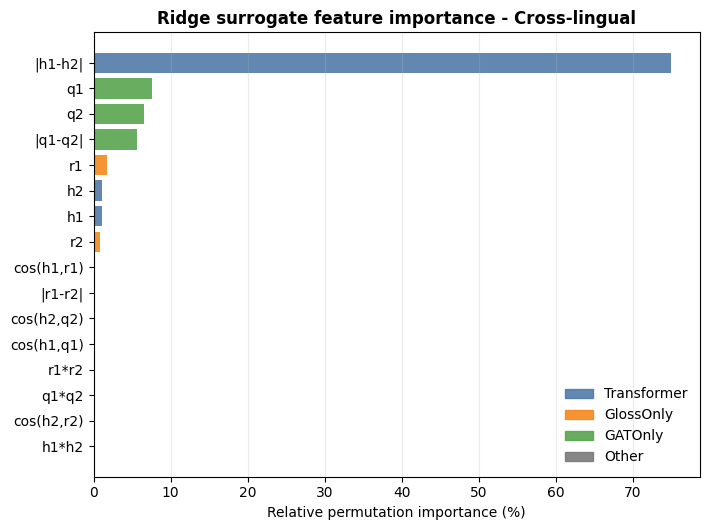

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_importance_pct_cross_lingual.png


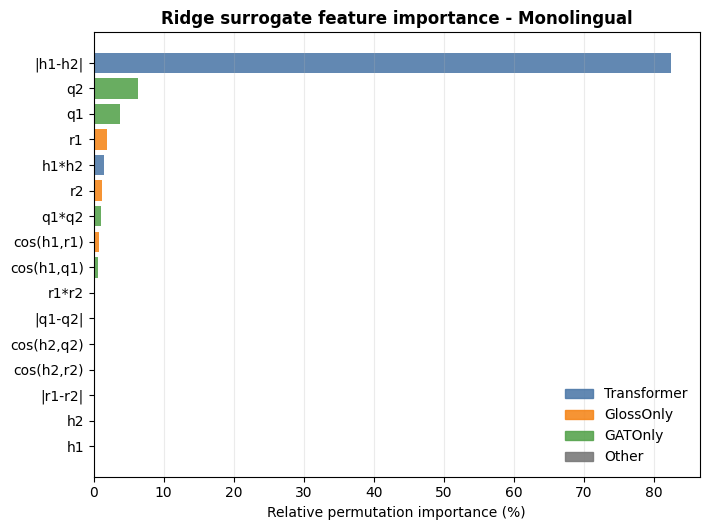

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_importance_pct_monolingual.png


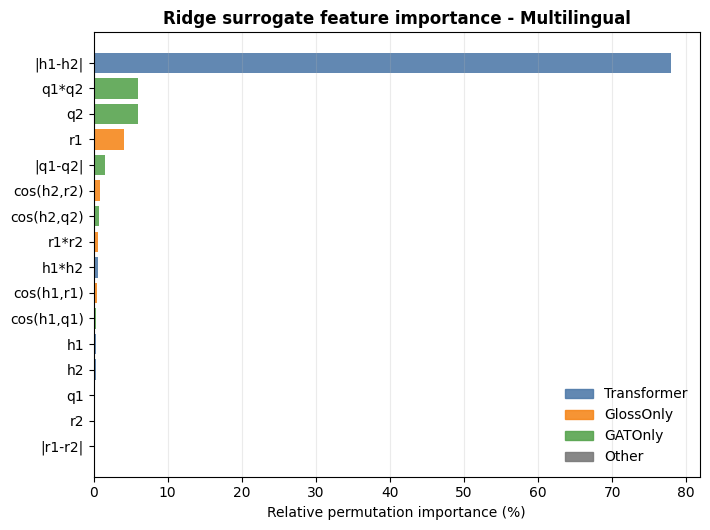

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_importance_pct_multilingual.png


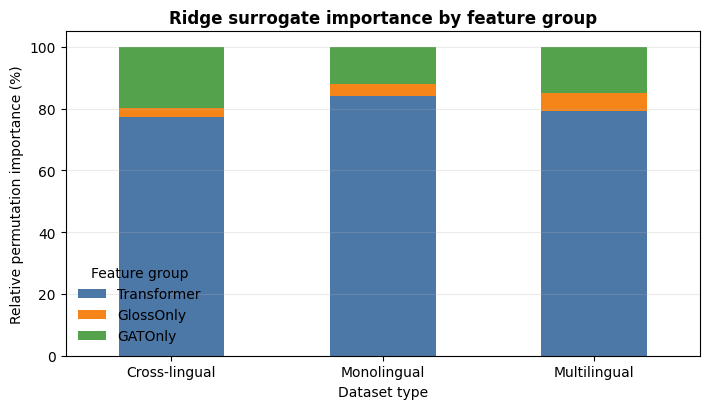

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_importance_grouped_pct.png


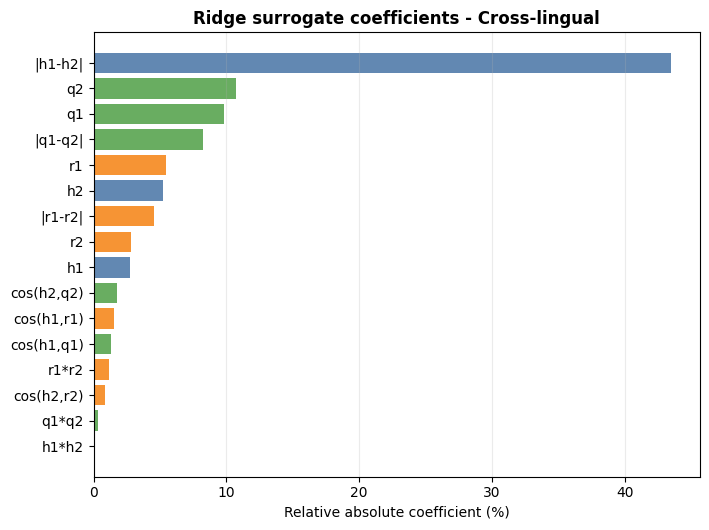

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_coefficients_pct_cross_lingual.png


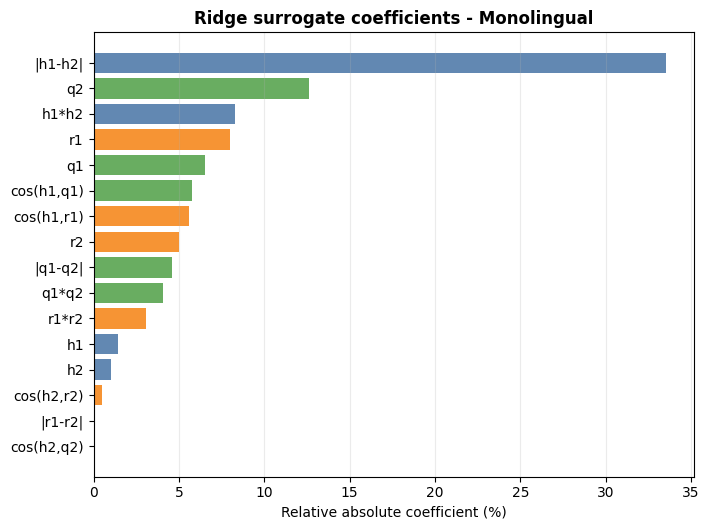

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_coefficients_pct_monolingual.png


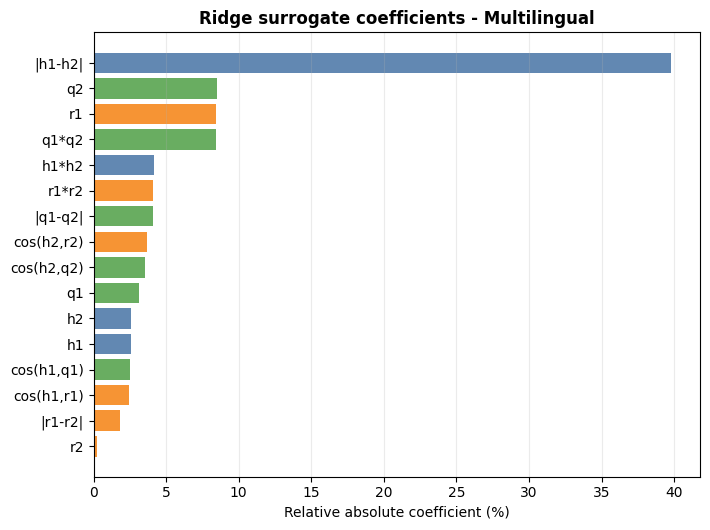

/content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/ridge_surrogate_coefficients_pct_multilingual.png


In [ ]:
if RUN_HEAVY_CELLS:
    pred, gat_model, tokenizer, rows_by_split, gat_hparams, cfg = build_prediction_artifacts(seed=SEED, force_retrain=False)
    device = common.pick_device(DEVICE)
    gat_loaders = build_meta_target_loaders(rows_by_split, tokenizer, cfg.max_len, gat_hparams['batch_size'], device=device)
    surrogate_df = extract_surrogate_dataset(gat_model, gat_loaders, TEST_SPLITS, device)
    surrogate_df.to_csv(OUTPUT_DIR / 'glosegat_surrogate_feature_blocks.csv', index=False)
    importance_df, surrogate_metrics_df, grouped_importance_df, ridge_coef_df = run_surrogate_importance(surrogate_df, ridge_alpha=1.0)
    importance_df.to_csv(OUTPUT_DIR / 'ridge_surrogate_feature_importance.csv', index=False)
    grouped_importance_df.to_csv(OUTPUT_DIR / 'ridge_surrogate_group_importance.csv', index=False)
    ridge_coef_df.to_csv(OUTPUT_DIR / 'ridge_surrogate_coefficients.csv', index=False)
    surrogate_metrics_df.to_csv(OUTPUT_DIR / 'ridge_surrogate_metrics.csv', index=False)
    display(surrogate_metrics_df)
    display(importance_df.sort_values(['dataset_type', 'importance_pct'], ascending=[True, False]).head(50))
    display(grouped_importance_df)
    display(ridge_coef_df.sort_values(['dataset_type', 'ridge_coef_pct'], ascending=[True, False]).head(50))
    plot_surrogate_importance(importance_df)
    plot_grouped_surrogate_importance(grouped_importance_df)
    plot_ridge_coefficients(ridge_coef_df)
else:
    print('Skipped. Set RUN_HEAVY_CELLS = True to extract GloSeGAT features and run Ridge surrogate interpretability.')


## 4. GNNExplainer-Style Explanation for a Correct Cross-Lingual Example

The project uses a custom dense GAT implementation rather than a PyTorch Geometric model. Therefore, the explainer below follows the same optimization principle as GNNExplainer: learn continuous node and edge masks that preserve the original prediction while encouraging sparse explanations.

The selected example must satisfy:

- split is cross-lingual;
- GloSeGAT prediction is correct;
- TargetPOS prediction is incorrect;
- the candidate sense graph has many senses.

In [36]:
def logits_from_glosegat_blocks(model, blocks):
    return model.classifier(torch.cat(blocks, dim=-1)).squeeze(-1)


def counterfactual_logits_without_graph(model, blocks):
    masked = list(blocks)
    # q1, q2, |q1-q2|, q1*q2, cos(h1,q1), cos(h2,q2)
    for idx in [10, 11, 12, 13, 14, 15]:
        masked[idx] = torch.zeros_like(masked[idx])
    return logits_from_glosegat_blocks(model, masked)


@torch.no_grad()
def score_graph_sensitivity_for_predictions(pred_df, model, loaders, max_candidates=300):
    """Rank candidate examples by how much the graph-refined q-blocks affect the GloSeGAT logit."""
    base_candidates = pred_df[
        pred_df['split'].isin(CROSSLINGUAL_SPLITS)
        & (pred_df['glosegat_correct'] == True)
        & (pred_df['targetpos_correct'] == False)
    ].copy()
    if base_candidates.empty:
        return base_candidates

    # Keep examples with several senses and avoid extremely saturated examples when possible.
    n_senses = []
    for _, row in base_candidates.iterrows():
        meta = model.sense_cache.get_synsets(row['lemma'], row['pos'], 'eng')
        n_senses.append(len(meta['synsets']))
    base_candidates['n_senses'] = n_senses
    base_candidates = base_candidates[base_candidates['n_senses'] >= 3].copy()
    base_candidates['confidence_distance'] = (base_candidates['glosegat_prob'] - 0.5).abs()
    base_candidates = base_candidates.sort_values(['n_senses', 'confidence_distance'], ascending=[False, True]).head(max_candidates)

    wanted = set(zip(base_candidates['id'], base_candidates['split']))
    score_rows = []
    device = next(model.parameters()).device
    model.eval()
    for split in CROSSLINGUAL_SPLITS:
        if hasattr(model, 'reset_sense_cache'):
            model.reset_sense_cache()
        for batch in loaders[split]:
            present = [(id_, split) in wanted for id_ in batch['ids']]
            if not any(present):
                continue
            batch_device = common.move_batch(batch, device)
            blocks, _, full_logits, _ = compose_glosegat_blocks(model, batch_device)
            no_graph_logits = counterfactual_logits_without_graph(model, blocks)
            full_probs = torch.sigmoid(full_logits).detach().cpu().numpy()
            no_graph_probs = torch.sigmoid(no_graph_logits).detach().cpu().numpy()
            full_logits_np = full_logits.detach().cpu().numpy()
            no_graph_logits_np = no_graph_logits.detach().cpu().numpy()
            for i, id_ in enumerate(batch['ids']):
                if (id_, split) not in wanted:
                    continue
                score_rows.append({
                    'id': id_,
                    'split': split,
                    'full_logit': float(full_logits_np[i]),
                    'no_graph_logit': float(no_graph_logits_np[i]),
                    'graph_logit_delta': float(abs(full_logits_np[i] - no_graph_logits_np[i])),
                    'full_prob': float(full_probs[i]),
                    'no_graph_prob': float(no_graph_probs[i]),
                    'graph_prob_delta': float(abs(full_probs[i] - no_graph_probs[i])),
                })
    score_df = pd.DataFrame(score_rows)
    if score_df.empty:
        return base_candidates
    ranked = base_candidates.merge(score_df, on=['id', 'split'], how='inner')
    return ranked.sort_values(['graph_logit_delta', 'n_senses', 'graph_prob_delta'], ascending=[False, False, False])


def choose_crosslingual_example(pred_df, model, loaders=None, top_n=20):
    if loaders is not None:
        ranked = score_graph_sensitivity_for_predictions(pred_df, model, loaders)
        if not ranked.empty:
            return ranked.head(top_n)
    candidates = pred_df[
        pred_df['split'].isin(CROSSLINGUAL_SPLITS)
        & (pred_df['glosegat_correct'] == True)
        & (pred_df['targetpos_correct'] == False)
    ].copy()
    counts = []
    for _, row in candidates.iterrows():
        meta = model.sense_cache.get_synsets(row['lemma'], row['pos'], 'eng')
        counts.append(len(meta['synsets']))
    candidates['n_senses'] = counts
    return candidates.sort_values(['n_senses', 'glosegat_prob'], ascending=[False, False]).head(top_n)


def minmax01(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    lo, hi = np.nanmin(x), np.nanmax(x)
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return np.ones_like(x)
    return (x - lo) / (hi - lo)


def explain_dense_gat_example(
    model,
    batch,
    instance_offset=0,
    steps=800,
    lr=0.03,
    edge_size=0.002,
    node_size=0.002,
    edge_entropy=0.0005,
    node_entropy=0.0005,
    init_bias=2.0,
):
    """Dense-mask explainer for the sense GAT.

    This preserves the original full logit rather than only the predicted class.
    Preserving only the class lets masks collapse to zero whenever contextual h-blocks
    already determine the label.
    """
    model.eval()
    device = next(model.parameters()).device
    batch_device = common.move_batch(batch, device)
    with torch.no_grad():
        base_blocks, _, base_logits, _ = compose_glosegat_blocks(model, batch_device)
        target_logit = base_logits[instance_offset:instance_offset+1].detach()
        target_prob = torch.sigmoid(target_logit).detach()
        no_graph_logit = counterfactual_logits_without_graph(model, base_blocks)[instance_offset:instance_offset+1].detach()

    lemma = batch['lemmas'][instance_offset]
    pos = batch['poses'][instance_offset]
    wn_lang = batch['wn_langs'][instance_offset]
    meta, gloss_emb = model.sense_cache.get_gloss_embeddings(lemma, pos, wn_lang, model.encoder, model.tokenizer, device, model.max_len)
    synsets = meta['synsets']
    if len(synsets) == 0:
        raise ValueError('Selected example has no candidate synsets.')
    adj = common.build_candidate_adj(synsets).to(device)

    node_logits = torch.nn.Parameter(torch.full((gloss_emb.size(0),), init_bias, device=device))
    edge_logits = torch.nn.Parameter(torch.full_like(adj, init_bias, device=device))
    opt = torch.optim.Adam([node_logits, edge_logits], lr=lr)

    h1 = model.encode_target(batch_device['input_ids_1'], batch_device['attention_mask_1'], batch_device['target_index_1'])[instance_offset:instance_offset+1].detach()
    h2 = model.encode_target(batch_device['input_ids_2'], batch_device['attention_mask_2'], batch_device['target_index_2'])[instance_offset:instance_offset+1].detach()
    gloss_emb = gloss_emb.detach()
    eye = torch.eye(adj.size(0), device=device)

    for step in range(steps):
        node_mask_flat = torch.sigmoid(node_logits)
        node_mask = node_mask_flat.unsqueeze(-1)
        raw_edge_mask = torch.sigmoid(edge_logits)
        edge_mask = raw_edge_mask * adj
        edge_mask = torch.maximum(edge_mask, eye)
        edge_mask = 0.5 * (edge_mask + edge_mask.T)

        masked_gloss = gloss_emb * node_mask
        graph_emb = model.sense_gat(masked_gloss, edge_mask)
        r1 = model.attend_candidates(h1, masked_gloss)
        r2 = model.attend_candidates(h2, masked_gloss)
        q1 = model.attend_candidates(h1, graph_emb)
        q2 = model.attend_candidates(h2, graph_emb)
        blocks = [
            h1, h2, (h1-h2).abs(), h1*h2,
            r1, r2, (r1-r2).abs(), r1*r2, model.cos(h1, r1).unsqueeze(-1), model.cos(h2, r2).unsqueeze(-1),
            q1, q2, (q1-q2).abs(), q1*q2, model.cos(h1, q1).unsqueeze(-1), model.cos(h2, q2).unsqueeze(-1),
        ]
        logit = logits_from_glosegat_blocks(model, blocks).view_as(target_logit)
        fidelity = F.mse_loss(logit, target_logit)
        node_prob = node_mask_flat.clamp(1e-6, 1 - 1e-6)
        edge_prob = raw_edge_mask[adj > 0].clamp(1e-6, 1 - 1e-6)
        node_ent = -(node_prob * torch.log(node_prob) + (1 - node_prob) * torch.log(1 - node_prob)).mean()
        edge_ent = -(edge_prob * torch.log(edge_prob) + (1 - edge_prob) * torch.log(1 - edge_prob)).mean() if edge_prob.numel() else torch.tensor(0.0, device=device)
        loss = fidelity + node_size * node_prob.mean() + edge_size * edge_prob.mean() + node_entropy * node_ent + edge_entropy * edge_ent
        opt.zero_grad()
        loss.backward()
        opt.step()

    node_score_raw = torch.sigmoid(node_logits).detach().cpu().numpy()
    edge_score_raw = (torch.sigmoid(edge_logits) * adj).detach().cpu().numpy()
    node_score = minmax01(node_score_raw)
    edge_score = minmax01(edge_score_raw)
    diagnostics = {
        'target_logit': float(target_logit.cpu()),
        'target_prob': float(target_prob.cpu()),
        'no_graph_logit': float(no_graph_logit.cpu()),
        'no_graph_prob': float(torch.sigmoid(no_graph_logit).cpu()),
        'graph_logit_delta': float(abs(target_logit.cpu().item() - no_graph_logit.cpu().item())),
        'node_score_raw_min': float(node_score_raw.min()),
        'node_score_raw_max': float(node_score_raw.max()),
    }
    return meta, adj.detach().cpu().numpy(), node_score, edge_score, diagnostics


In [37]:
import textwrap
import networkx as nx
from matplotlib import patheffects as pe


def clean_synset_label(name):
    parts = name.split('.')
    if len(parts) >= 3:
        return f'{parts[0]}.{parts[1]}.{parts[2]}'
    return name


def short_gloss(gloss, max_chars=78):
    if not gloss:
        return ''
    # Remove the duplicated lemma/POS prefix when possible.
    text = gloss.split(': ', 1)[-1]
    text = text.replace('\n', ' ').strip()
    if len(text) > max_chars:
        text = text[:max_chars].rsplit(' ', 1)[0] + '...'
    return text


def plot_sense_graph(meta, adj, node_score, edge_score, title, path, top_k_descriptions=7):
    names = meta['names']
    glosses = meta['glosses']
    G = nx.Graph()
    for i, name in enumerate(names):
        G.add_node(
            i,
            label=clean_synset_label(name),
            score=float(node_score[i]),
            gloss=short_gloss(glosses[i] if i < len(glosses) else ''),
        )
    for i in range(adj.shape[0]):
        for j in range(i + 1, adj.shape[1]):
            if adj[i, j] > 0:
                G.add_edge(i, j, weight=float(edge_score[i, j]))

    scores = np.array([G.nodes[n]['score'] for n in G.nodes])
    edge_weights = np.array([G.edges[e]['weight'] for e in G.edges]) if G.number_of_edges() else np.array([])
    pos = nx.spring_layout(G, seed=42, weight='weight', k=1.4, iterations=300)

    fig = plt.figure(figsize=(13.5, 7.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.04)
    ax = fig.add_subplot(gs[0, 0])
    ax_text = fig.add_subplot(gs[0, 1])

    if G.number_of_edges():
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            width=0.8 + 5.2 * edge_weights,
            alpha=np.clip(0.18 + 0.75 * edge_weights, 0.18, 0.95),
            edge_color=edge_weights,
            edge_cmap=plt.cm.Greys,
            edge_vmin=0,
            edge_vmax=1,
        )

    node_sizes = 850 + 1450 * scores
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=scores,
        cmap='viridis',
        vmin=0, vmax=1,
        node_size=node_sizes,
        linewidths=1.6,
        edgecolors='white',
    )
    labels = {n: G.nodes[n]['label'] for n in G.nodes}
    text_artists = nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold', font_color='white', ax=ax)
    for artist in text_artists.values():
        artist.set_path_effects([pe.withStroke(linewidth=2.6, foreground='black', alpha=0.55)])

    cbar = fig.colorbar(nodes, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label('Relative node importance')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

    ax_text.axis('off')
    ax_text.set_title('Candidate sense descriptions', fontsize=12, fontweight='bold', loc='left', pad=8)
    ranked_nodes = sorted(G.nodes, key=lambda n: G.nodes[n]['score'], reverse=True)[:top_k_descriptions]
    y = 0.98
    for rank, n in enumerate(ranked_nodes, start=1):
        score = G.nodes[n]['score']
        label = G.nodes[n]['label']
        gloss = G.nodes[n]['gloss']
        wrapped = textwrap.fill(gloss, width=48)
        color = plt.cm.viridis(score)
        ax_text.scatter([0.02], [y - 0.01], s=170, color=color, edgecolor='black', linewidth=0.4, transform=ax_text.transAxes)
        ax_text.text(0.07, y, f'{rank}. {label}  ({100*score:.1f}%)', transform=ax_text.transAxes, fontsize=10, fontweight='bold', va='top')
        ax_text.text(0.07, y - 0.055, wrapped, transform=ax_text.transAxes, fontsize=9, va='top', color='#333333')
        y -= 0.145 + 0.018 * max(0, wrapped.count('\n'))
        if y < 0.05:
            break

    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    return path


def plot_multiple_sense_graphs(explanations, output_path):
    """Create a compact multi-example panel. Each item is (meta, adj, node_score, edge_score, title)."""
    n = len(explanations)
    if n == 0:
        return None
    fig, axes = plt.subplots(n, 1, figsize=(9.5, 4.6 * n))
    if n == 1:
        axes = [axes]
    for ax, (meta, adj, node_score, edge_score, title) in zip(axes, explanations):
        G = nx.Graph()
        for i, name in enumerate(meta['names']):
            G.add_node(i, label=clean_synset_label(name), score=float(node_score[i]))
        for i in range(adj.shape[0]):
            for j in range(i + 1, adj.shape[1]):
                if adj[i, j] > 0:
                    G.add_edge(i, j, weight=float(edge_score[i, j]))
        scores = np.array([G.nodes[n]['score'] for n in G.nodes])
        eweights = np.array([G.edges[e]['weight'] for e in G.edges]) if G.number_of_edges() else np.array([])
        pos = nx.spring_layout(G, seed=42, weight='weight', k=1.3, iterations=250)
        if G.number_of_edges():
            nx.draw_networkx_edges(G, pos, ax=ax, width=0.7 + 4.5 * eweights, alpha=np.clip(0.2 + 0.7 * eweights, 0.2, 0.9), edge_color='#555555')
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=scores, cmap='viridis', vmin=0, vmax=1, node_size=700 + 1200 * scores, linewidths=1.2, edgecolors='white')
        labs = nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in G.nodes}, font_size=9, font_weight='bold', font_color='white', ax=ax)
        for artist in labs.values():
            artist.set_path_effects([pe.withStroke(linewidth=2.4, foreground='black', alpha=0.55)])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    return output_path


,id,split,lemma,pos,label,glosegat_prob,glosegat_pred,targetpos_prob,targetpos_pred,n_senses,graph_logit_delta,no_graph_prob
299,test.en-ru.697,test.en-ru,helpless,ADJ,1,0.925038,1,6.422228e-05,0,3,7.090566,0.010174
286,test.en-ru.696,test.en-ru,helpless,ADJ,1,0.732090,1,1.775035e-02,0,3,6.992626,0.002504
254,test.en-zh.965,test.en-zh,peculiar,ADJ,1,0.999806,1,4.896199e-01,0,4,6.992342,0.825823
264,test.en-ar.964,test.en-ar,peculiar,ADJ,1,0.999950,1,2.024281e-01,0,4,6.908917,0.952055
220,test.en-zh.964,test.en-zh,peculiar,ADJ,1,0.959144,1,1.367303e-01,0,4,6.851389,0.024235
180,test.en-zh.164,test.en-zh,age,NOUN,1,0.999873,1,4.863656e-01,0,5,6.735677,0.903172
228,test.en-ar.965,test.en-ar,peculiar,ADJ,1,0.987096,1,1.842083e-02,0,4,6.719734,0.084516
175,test.en-zh.744,test.en-zh,ripe,ADJ,1,0.999066,1,4.795375e-01,0,5,6.683733,0.572257
255,test.en-ar.222,test.en-ar,specific,ADJ,1,0.999820,1,2.778439e-01,0,4,6.667166,0.875711
158,test.en-fr.165,test.en-fr,age,NOUN,1,0.964024,1,5.903136e-02,0,5,6.650631,0.033493


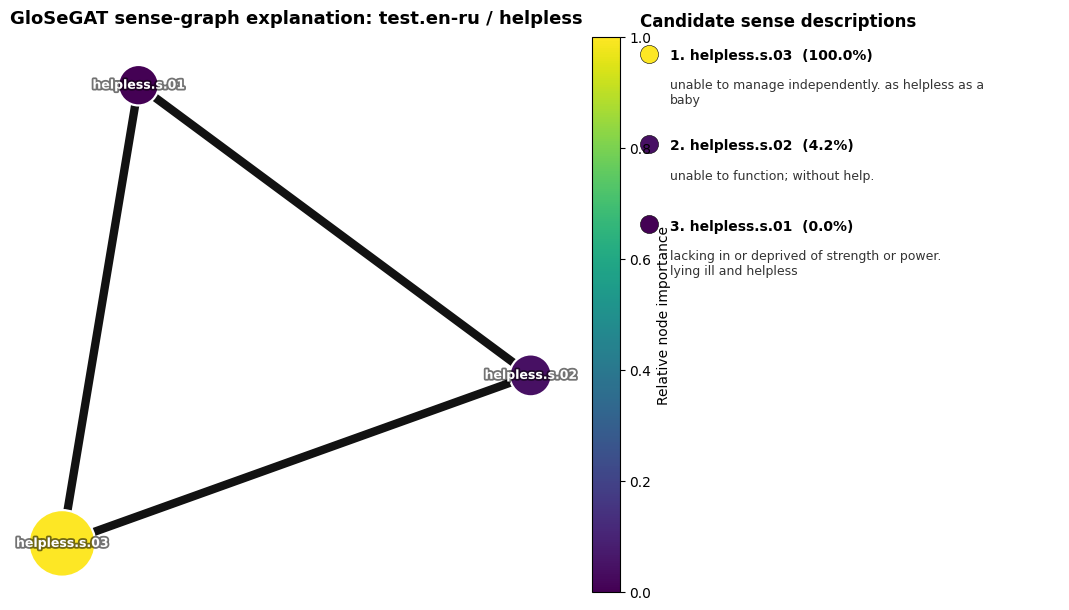

Best explanation diagnostics: {'target_logit': 2.5128419399261475, 'target_prob': 0.925037145614624, 'no_graph_logit': -4.577723503112793, 'no_graph_prob': 0.010173700749874115, 'graph_logit_delta': 7.09056544303894, 'node_score_raw_min': 0.9932608008384705, 'node_score_raw_max': 0.9951943755149841}
Graph saved to: /content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/gnn_explainer_selected_sense_graph.png


,candidate_rank,id,split,lemma,synset,gloss,node_importance_pct,diagnostic_graph_logit_delta,target_prob,no_graph_prob
2,1,test.en-ru.697,test.en-ru,helpless,helpless.s.03,helpless (s): unable to manage independently. ...,100.000000,7.090565,0.925037,0.010174
1,1,test.en-ru.697,test.en-ru,helpless,helpless.s.02,helpless (s): unable to function; without help.,4.241677,7.090565,0.925037,0.010174
0,1,test.en-ru.697,test.en-ru,helpless,helpless.s.01,helpless (s): lacking in or deprived of streng...,0.000000,7.090565,0.925037,0.010174
5,2,test.en-ru.696,test.en-ru,helpless,helpless.s.03,helpless (s): unable to manage independently. ...,100.000000,6.992626,0.732087,0.002504
3,2,test.en-ru.696,test.en-ru,helpless,helpless.s.01,helpless (s): lacking in or deprived of streng...,11.353383,6.992626,0.732087,0.002504
4,2,test.en-ru.696,test.en-ru,helpless,helpless.s.02,helpless (s): unable to function; without help.,0.000000,6.992626,0.732087,0.002504
7,3,test.en-zh.965,test.en-zh,peculiar,particular.s.01,particular (s): unique or specific to a person...,100.000000,6.992342,0.999806,0.825823
8,3,test.en-zh.965,test.en-zh,peculiar,peculiar.s.03,peculiar (s): markedly different from the usua...,94.854954,6.992342,0.999806,0.825823
9,3,test.en-zh.965,test.en-zh,peculiar,peculiar.s.04,peculiar (s): characteristic of one only; dist...,78.384075,6.992342,0.999806,0.825823
6,3,test.en-zh.965,test.en-zh,peculiar,curious.s.01,curious (s): beyond or deviating from the usua...,0.000000,6.992342,0.999806,0.825823


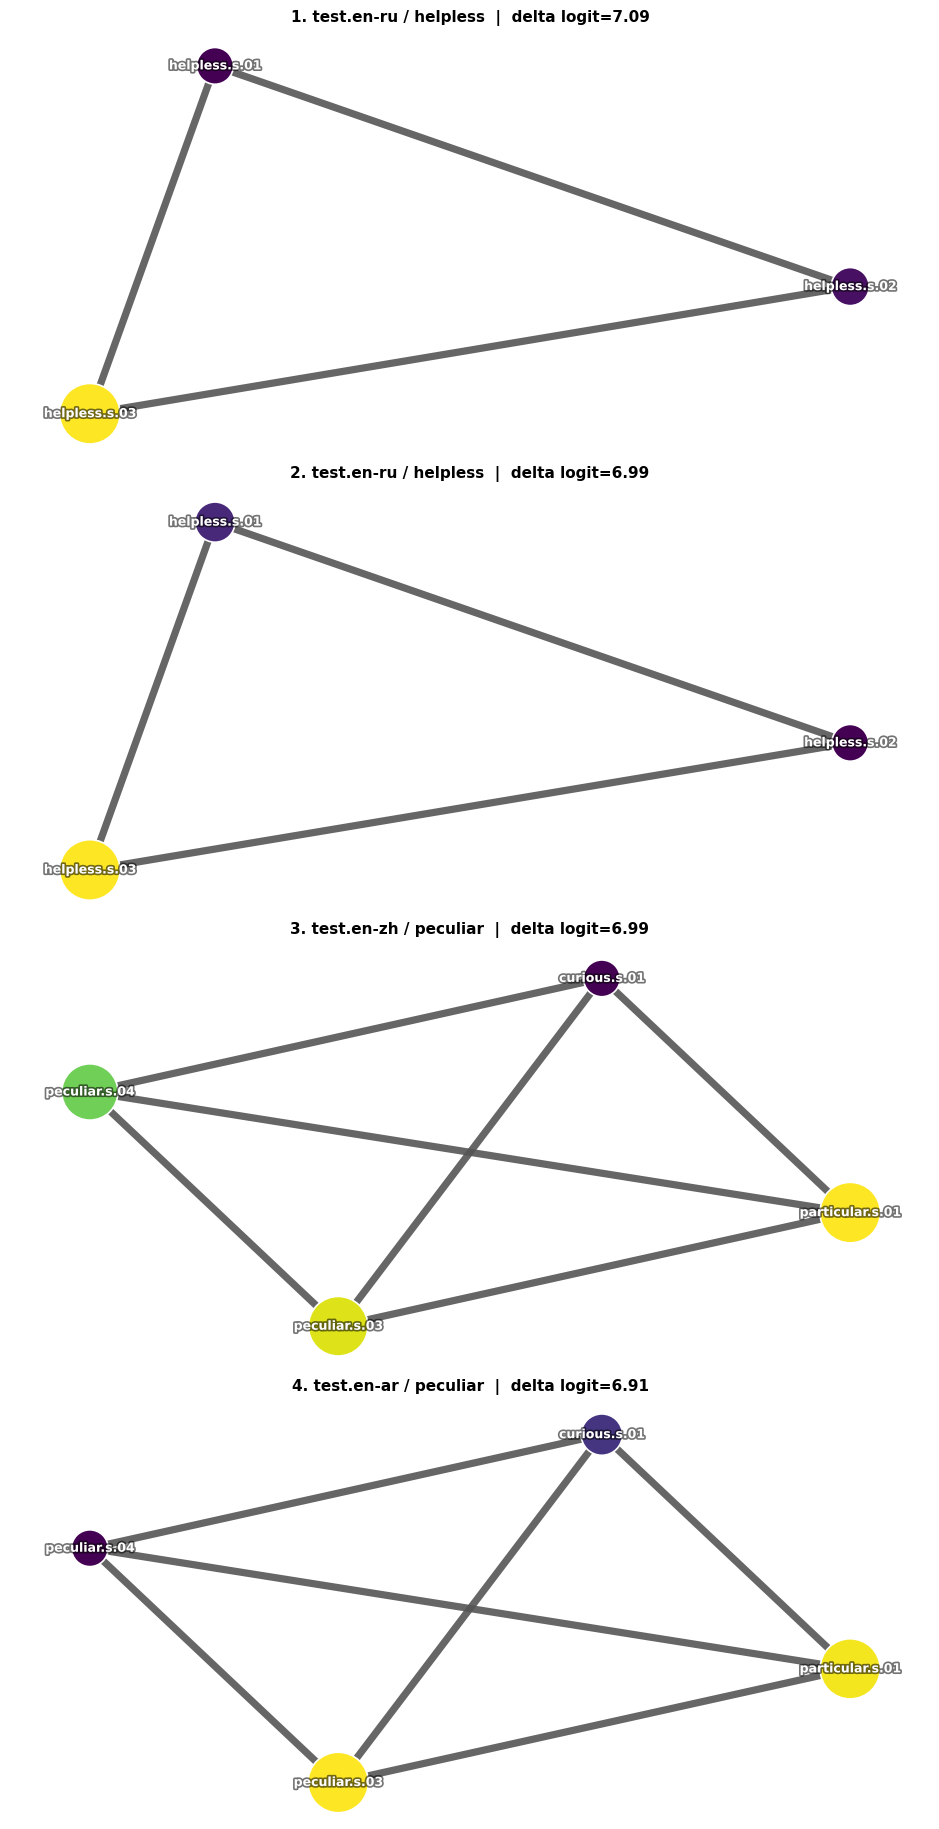

Panel saved to: /content/drive/MyDrive/MCL-WiC/Experiments/glosegat_mbert_analysis_outputs/gnn_explainer_sense_graph_panel.png


In [38]:
if RUN_HEAVY_CELLS:
    pred_path = OUTPUT_DIR / 'glosegat_targetpos_instance_predictions.csv'
    if pred_path.exists():
        pred = pd.read_csv(pred_path)
    else:
        pred, gat_model, tokenizer, rows_by_split, gat_hparams, cfg = build_prediction_artifacts(seed=SEED, force_retrain=False)

    device = common.pick_device(DEVICE)
    if 'gat_model' not in globals():
        gat_model, tokenizer, rows_by_split, gat_hparams, cfg = train_model_with_checkpoint('glowic_gat', seed=SEED, force_retrain=False)
    gat_loaders = build_meta_target_loaders(rows_by_split, tokenizer, cfg.max_len, batch_size=1, device=device)

    candidates = choose_crosslingual_example(pred, gat_model, loaders=gat_loaders, top_n=20)
    display(candidates[[col for col in ['id', 'split', 'lemma', 'pos', 'label', 'glosegat_prob', 'glosegat_pred', 'targetpos_prob', 'targetpos_pred', 'n_senses', 'graph_logit_delta', 'no_graph_prob'] if col in candidates.columns]])
    if candidates.empty:
        raise ValueError('No cross-lingual example matched the condition: GloSeGAT correct and TargetPOS incorrect.')

    explanations_for_panel = []
    all_node_rows = []
    for rank, (_, chosen) in enumerate(candidates.head(4).iterrows(), start=1):
        chosen_split = chosen['split']
        target_id = chosen['id']
        selected_batch = None
        selected_offset = 0
        for batch in gat_loaders[chosen_split]:
            if target_id in batch['ids']:
                selected_batch = batch
                selected_offset = batch['ids'].index(target_id)
                break
        if selected_batch is None:
            continue

        meta, adj, node_score, edge_score, diagnostics = explain_dense_gat_example(gat_model, selected_batch, selected_offset)
        title = f'{rank}. {chosen_split} / {chosen["lemma"]}  |  delta logit={diagnostics["graph_logit_delta"]:.2f}'
        explanations_for_panel.append((meta, adj, node_score, edge_score, title))
        for i, name in enumerate(meta['names']):
            all_node_rows.append({
                'candidate_rank': rank,
                'id': target_id,
                'split': chosen_split,
                'lemma': chosen['lemma'],
                'synset': name,
                'gloss': meta['glosses'][i],
                'node_importance_pct': 100 * node_score[i],
                'diagnostic_graph_logit_delta': diagnostics['graph_logit_delta'],
                'target_prob': diagnostics['target_prob'],
                'no_graph_prob': diagnostics['no_graph_prob'],
            })
        if rank == 1:
            graph_path = OUTPUT_DIR / 'gnn_explainer_selected_sense_graph.png'
            plot_sense_graph(meta, adj, node_score, edge_score, f'GloSeGAT sense-graph explanation: {chosen_split} / {chosen["lemma"]}', graph_path)
            print('Best explanation diagnostics:', diagnostics)
            print('Graph saved to:', graph_path)

    explanation_df = pd.DataFrame(all_node_rows).sort_values(['candidate_rank', 'node_importance_pct'], ascending=[True, False])
    explanation_df.to_csv(OUTPUT_DIR / 'gnn_explainer_selected_example_nodes.csv', index=False)
    display(explanation_df)

    panel_path = OUTPUT_DIR / 'gnn_explainer_sense_graph_panel.png'
    plot_multiple_sense_graphs(explanations_for_panel, panel_path)
    print('Panel saved to:', panel_path)
else:
    print('Skipped. Set RUN_HEAVY_CELLS = True to train/load models and run the GNNExplainer-style analysis.')


## Notes on the Ablation Protocol

The ablation training section now includes all five requested stages:

1. `PairCLS`: BERT [CLS] baseline.
2. `TargetSim`: target-aware Transformer.
3. `GlossOnly`: target-aware Transformer + dictionary/gloss sense attention, no graph refinement.
4. `GATOnly`: target-aware Transformer + graph-refined sense representations, without raw gloss features in the classifier.
5. `GloSeGAT`: complete architecture with dictionary/gloss sense attention and graph-refined sense representations.

All five stages are trained from scratch with the same best hyperparameters selected for mBERT GloSeGAT. The surrogate section can then quantify how much the raw gloss blocks (`r`) and graph-refined blocks (`q`) contribute inside the complete model.